# GII Analysis

**Data Preprocessing**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import pycountry
import seaborn as sns

In [ ]:
# Load the datasets
crs_df = pd.read_csv("crs_data.csv", encoding='utf-8')
hdr_df = pd.read_csv("data/raw/undp_hdr/HDR25_Composite_indices_complete_time_series.csv", encoding='latin1')


/tmp/ipykernel_465553/3328979821.py:2: DtypeWarning: Columns (6,7,9,11,12,13,15,18,19,22,23,27,28,30,31,32,34,35,36,37,38,39,46,47,48,49,50,51,52,53,54,55,57,59,60,61,62,63,64,79,80,81,84,86,87,94,95,96,97) have mixed types. Specify dtype option on import or set low_memory=False.
  crs_df = pd.read_csv("crs_data.csv", encoding='utf-8')


In [19]:
hdr_df.head()

,iso3,Country,hdicode,region,hdi_rank_2023,hdi_1990,hdi_1991,hdi_1992,hdi_1993,hdi_1994,...,co2_prod_1994,co2_prod_1995,co2_prod_1996,co2_prod_1997,co2_prod_1998,co2_prod_1999,co2_prod_2000,co2_prod_2001,co2_prod_2002,co2_prod_2003
0,AFG,Afghanistan,Low,SA,181.0,0.285,0.291,0.301,0.311,0.305,...,0.094063,0.086321,0.080092,0.073316,0.069134,0.056669,0.053579,0.054300,0.063856,0.068871
1,ALB,Albania,Very High,ECA,71.0,0.654,0.638,0.622,0.624,0.629,...,0.584032,0.636074,0.616721,0.474227,0.542885,0.930785,0.950622,1.021273,1.200012,1.391372
2,DZA,Algeria,High,AS,96.0,0.595,0.596,0.601,0.603,0.603,...,3.171721,3.398301,3.451463,2.998009,3.560160,3.013539,2.774968,2.783223,2.867771,2.950491
3,AND,Andorra,Very High,NaN,32.0,NaN,NaN,NaN,NaN,NaN,...,6.663172,6.754068,7.082794,7.194119,7.531985,7.812962,7.926986,7.725597,7.498765,7.238015
4,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,0.843350,0.906877,1.060184,1.068122,1.074604,1.087617,0.975664,0.939021,0.918011,0.964692


**Filtering the CRS dataframe**

In [20]:
# --- Select and Clean CRS ---
fields_to_keep = ['RecipientName', 'Year', 'Gender', 'ClimateMitigation',
                  'ClimateAdaptation', 'USD_Commitment', 'USD_Disbursement']

crs_agg = crs_df[fields_to_keep].copy()
crs_agg = crs_agg.rename(columns={'RecipientName': 'Country'})

# Handle NaNs by treating them as 0
crs_agg[['Gender', 'ClimateMitigation', 'ClimateAdaptation']] = crs_agg[
    ['Gender', 'ClimateMitigation', 'ClimateAdaptation']
].fillna(0)

# --- Step 2: Classify aid type (exclude 'None' later) ---
def classify_aid(row):
    gender = row['Gender'] != 0
    climate = (row['ClimateMitigation'] != 0) | (row['ClimateAdaptation'] != 0)
    
    if gender and climate:
        return 'Both'
    elif gender:
        return 'Gender'
    elif climate:
        return 'Climate'
    else:
        return 'Others'

crs_agg['Aid_Objective'] = crs_agg.apply(classify_aid, axis=1)


In [21]:
crs_agg

,Country,Year,Gender,ClimateMitigation,ClimateAdaptation,USD_Commitment,USD_Disbursement,Aid_Objective
0,Tunisia,2014,1.0,0.0,0.0,0.161292,0.161292,Gender
1,Afghanistan,2014,1.0,0.0,0.0,4.385697,1.953164,Gender
2,"Bilateral, unspecified",2014,0.0,0.0,0.0,0.690275,0.105570,Others
3,"Bilateral, unspecified",2014,0.0,0.0,0.0,0.050500,0.050500,Others
4,"Bilateral, unspecified",2014,1.0,0.0,0.0,0.023440,0.023121,Gender
...,...,...,...,...,...,...,...,...
3843377,41000,2023,0.0,0.0,0,0.000000,0.000000,Others
3843378,47000,2023,0.0,0.0,0,2.000000,0.000000,Others
3843379,47000,2023,0.0,0.0,0,2.000000,0.000000,Others
3843380,47000,2023,0.0,0.0,0,2.000000,0.000000,Others


In [22]:
#Merging CRS and HDR
crs_agg_for_merge = crs_agg[['Country', 'Year', 'Aid_Objective', 'USD_Disbursement', 'USD_Commitment']].copy()

valid_countries = set(country.name for country in pycountry.countries)
hdr_filtered = hdr_df[hdr_df['Country'].isin(valid_countries)]

rename_map = {
    'abr_':'AdolescentBirthRate','eys_f_':'ExpectedYearsSchoolingF','eys_m_':'ExpectedYearsSchoolingM',
    'gii_':'GlobalInequalityIndex','gii_rank_':'GIIRank','gni_pc_f_':'GrossIncomeCapitaF',
    'gni_pc_m_':'GrossIncomeCapitaM','hdi_f_':'HDIF','hdi_m_':'HDIM','le_f_':'LifeExpectancyF',
    'le_m_':'LifeExpectancyM','lfpr_f_':'LaborForceParticipationF','lfpr_m_':'LaborForceParticipationM',
    'mmr_':'MaternalMortalityRatio','mys_f_':'MeanYearsSchoolingF','mys_m_':'MeanYearsSchoolingM',
    'pr_f_':'ParliamentF','pr_m_':'ParliamentM','se_f_':'SecondaryEducF','se_m_':'SecondaryEducM'
}

prefixes = list(rename_map.keys())

hdr_long = (
    hdr_filtered[['Country'] + [c for c in hdr_filtered if any(c.startswith(p) for p in prefixes)]]
    .melt(id_vars='Country', var_name='indicator_year', value_name='value')
)

hdr_long[['indicator','Year']] = hdr_long['indicator_year'].str.extract(r'^([a-zA-Z_]+)(\d{4})')
hdr_long['Year'] = hdr_long['Year'].astype(float)


hdr_pivot = hdr_long.pivot(index=['Country','Year'], columns='indicator', values='value').reset_index()
crs_agg_for_merge['Year'] = crs_agg_for_merge['Year'].astype(float)
hdr_pivot['Year'] = hdr_pivot['Year'].astype(float)
merged_df = crs_agg_for_merge.merge(hdr_pivot, on=['Country','Year'], how='left')


merged_df.rename(
    columns=lambda c: next((re.sub(f'^{p}', n, c) for p, n in rename_map.items() if c.startswith(p)), c),
    inplace=True
)
merged_df



,Country,Year,Aid_Objective,USD_Disbursement,USD_Commitment,AdolescentBirthRate,ExpectedYearsSchoolingF,ExpectedYearsSchoolingM,GlobalInequalityIndex,GlobalInequalityIndexrank_,...,LifeExpectancyM,LaborForceParticipationF,LaborForceParticipationM,MaternalMortalityRatio,MeanYearsSchoolingF,MeanYearsSchoolingM,ParliamentF,ParliamentM,SecondaryEducF,SecondaryEducM
0,Tunisia,2014.0,Gender,0.161292,0.161292,8.568,14.913344,13.702094,0.280,NaN,...,72.406,21.14,63.42,40.560891,6.110000,7.86000,31.336406,68.663594,31.816338,41.295113
1,Afghanistan,2014.0,Gender,1.953164,4.385697,84.069,8.047050,12.767480,0.687,NaN,...,60.495,25.78,77.08,785.354018,0.710609,3.36199,27.635328,72.364672,3.441748,18.542849
2,"Bilateral, unspecified",2014.0,Others,0.105570,0.690275,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Bilateral, unspecified",2014.0,Others,0.050500,0.050500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Bilateral, unspecified",2014.0,Gender,0.023121,0.023440,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3843377,41000,2023.0,Others,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3843378,47000,2023.0,Others,0.000000,2.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3843379,47000,2023.0,Others,0.000000,2.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3843380,47000,2023.0,Others,0.000000,2.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## Research questions

Q1. What is the trend of Aid Objectives for climate, gender and both over time?

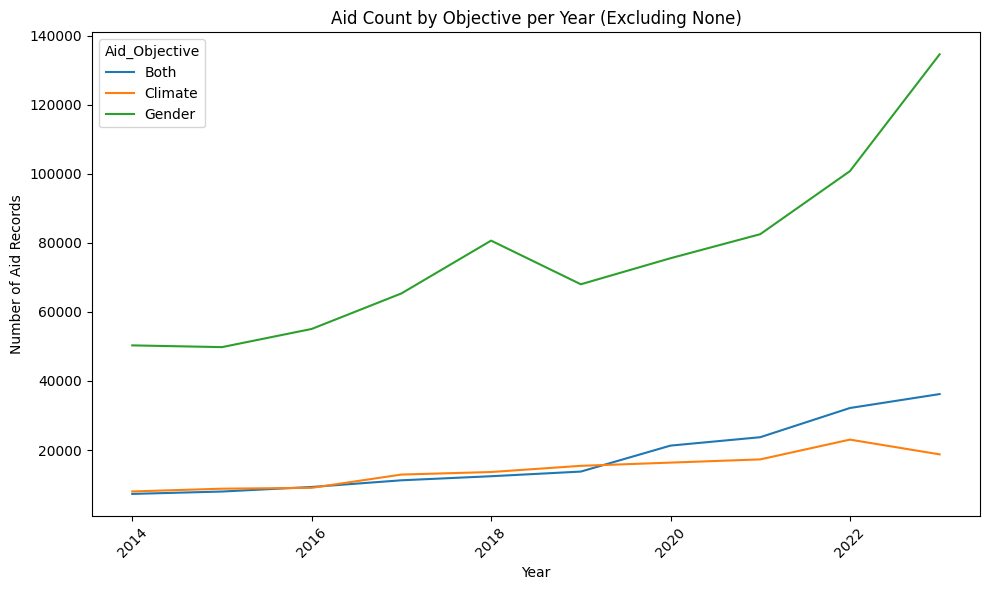

In [37]:
#Getting the Number of Aids
filtered = crs_agg[crs_agg['Aid_Objective'] != 'Others']
aid_counts = filtered.groupby(['Year', 'Aid_Objective']).size().reset_index(name='count')
aid_pivot = aid_counts.pivot(index='Year', columns='Aid_Objective', values='count').fillna(0)

aid_pivot.plot(kind='line', figsize=(10, 6))
plt.ylabel('Number of Aid Records')
plt.title('Aid Count by Objective per Year (Excluding None)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Between 2014 and 2023, there is an upward trend in the number of gender-focused aid projects. Although aid initiatives addressing both gender and climate objectives have also increased during this period, their overall volume along with Climate only aid remains considerably lower compared to gender-focused aid.

---

Q2. Does gender-focused aid correlate with improvements in gender inequality (GII) over time?

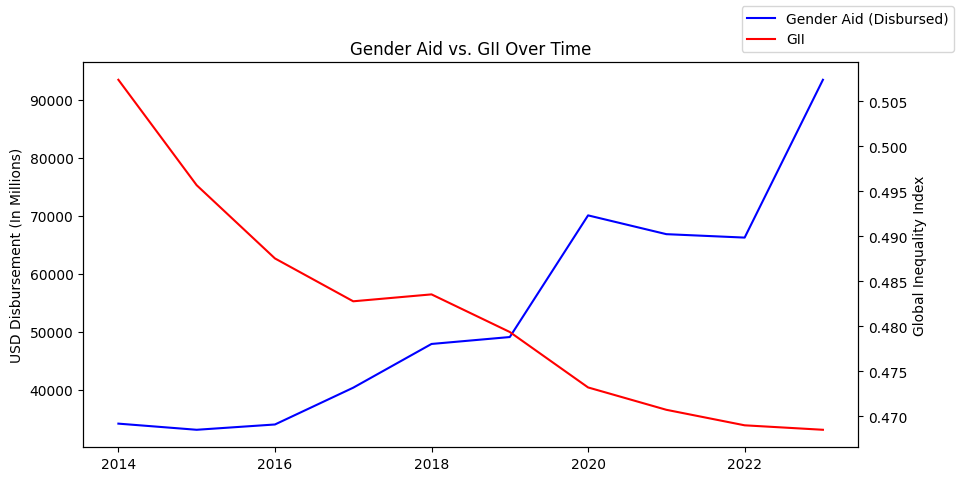

In [38]:
# Filter gender-focused aid
gender_aid = merged_df[merged_df['Aid_Objective'] == 'Gender']

# Group by year, calculate total disbursement and mean GII
g1 = gender_aid.groupby('Year').agg({
    'USD_Disbursement': 'sum',
    'GlobalInequalityIndex': 'mean'
}).reset_index()

# Plot
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(g1['Year'], g1['USD_Disbursement'], label='Gender Aid (Disbursed)', color='blue')
ax2 = ax1.twinx()
ax2.plot(g1['Year'], g1['GlobalInequalityIndex'], label='GII', color='red')
ax1.set_ylabel('USD Disbursement (In Millions)')
ax2.set_ylabel('Global Inequality Index')
plt.title('Gender Aid vs. GII Over Time')
fig.legend(loc="upper right")
plt.show()

From 2014 to 2023, the overall Gender Inequality Index (GII) has shown a significant decline, coinciding with an increase in gender-focused aid. This trend suggests that the growing emphasis on gender-targeted initiatives has been effective in contributing to improvements in gender equality outcomes.

---

Q2. How do climate-focused aid and gender-focused aid interact in shaping gender outcomes?

Average gender-related indicators by Aid Type:
               GlobalInequalityIndex  SecondaryEducF  \
Aid_Objective                                          
Both                        0.488011       35.993893   
Climate                     0.442312       45.907600   
Gender                      0.478927       38.559461   
Others                      0.452257       44.379417   

               LaborForceParticipationF  ParliamentF  
Aid_Objective                                         
Both                          51.602187    24.170154  
Climate                       49.396939    23.029463  
Gender                        48.539940    22.998071  
Others                        48.547202    22.520953  


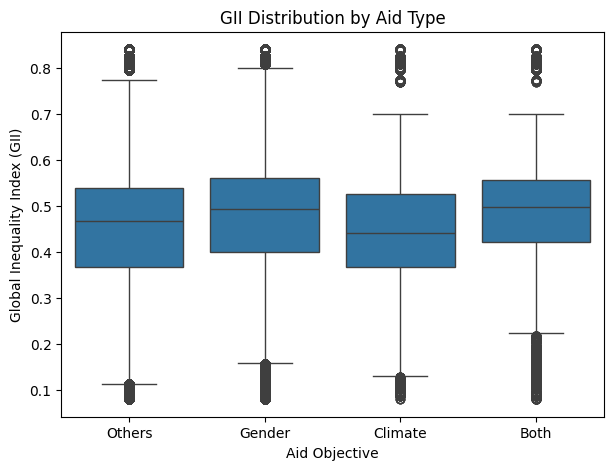

In [40]:
df = merged_df.copy()

print("Average gender-related indicators by Aid Type:")
print(df.groupby('Aid_Objective')[['GlobalInequalityIndex', 'SecondaryEducF', 'LaborForceParticipationF', 'ParliamentF']].mean())

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Aid_Objective', y='GlobalInequalityIndex')
plt.title("GII Distribution by Aid Type")
plt.ylabel("Global Inequality Index (GII)")
plt.xlabel("Aid Objective")
plt.show()


While climate-focused aid is associated with lower GII and higher female education levels, both-focused aid tends to target countries with higher inequality. These findings suggest that gender outcomes vary by aid objective, and interventions addressing both climate and gender may be directed at more challenging contexts, where improvements take longer to materialize.

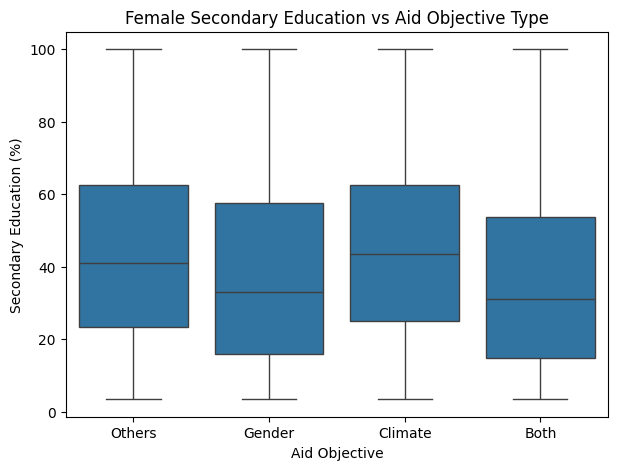

In [41]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Aid_Objective', y='SecondaryEducF')
plt.title("Female Secondary Education vs Aid Objective Type")
plt.ylabel("Secondary Education (%)")
plt.xlabel("Aid Objective")
plt.show()

df['aid_intensity'] = pd.qcut(df['USD_Disbursement'].fillna(0), 3, labels=['Low', 'Medium', 'High'])


Female secondary education levels are highest in countries receiving climate-focused aid, while gender-focused and both-focused aid are associated with lower median education outcomes. This pattern suggests that climate aid may be directed toward countries with relatively stronger educational infrastructure, whereas gender-targeted interventions are concentrated in contexts where education inequalities are more pronounced

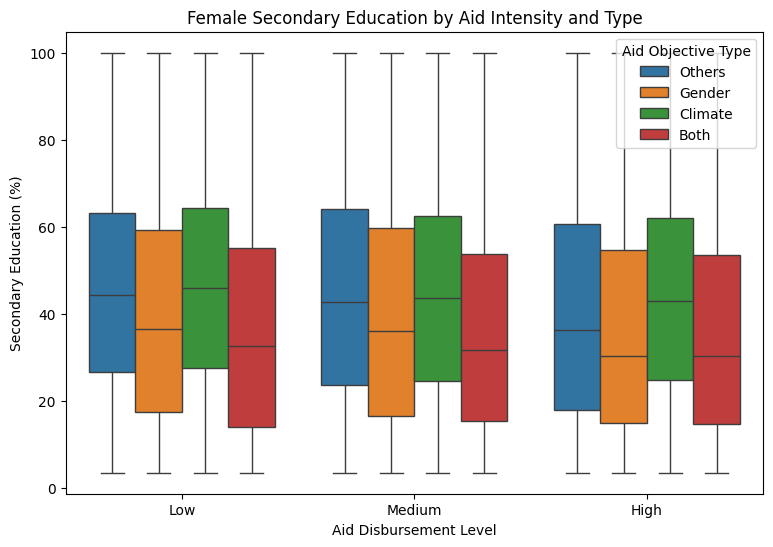


Correlation between Aid Disbursement, GII, and Female Education:
                       USD_Disbursement  GlobalInequalityIndex  SecondaryEducF
USD_Disbursement               1.000000               0.000153        0.003806
GlobalInequalityIndex          0.000153               1.000000       -0.730205
SecondaryEducF                 0.003806              -0.730205        1.000000


In [42]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x='aid_intensity', y='SecondaryEducF', hue='Aid_Objective')
plt.title("Female Secondary Education by Aid Intensity and Type")
plt.ylabel("Secondary Education (%)")
plt.xlabel("Aid Disbursement Level")
plt.legend(title="Aid Objective Type")
plt.show()


corr = df[['USD_Disbursement', 'GlobalInequalityIndex', 'SecondaryEducF']].corr()
print("\nCorrelation between Aid Disbursement, GII, and Female Education:")
print(corr)

Comparing the female secondary education across different aid levels, climate aid countries tend to perform better, showing higher education rates. Aid intensity (low, medium, high) does not significantly change education outcomes, suggesting that how aid is targeted may matter more than how much is spent. Countries receiving aid that targets both gender and climate objectives often have lower education levels, possibly because these programs focus on more challenging contexts where gender gaps are still large.

---

Q3. Are there lag effects between aid allocation and gender development outcomes?

In [29]:
merged_df = merged_df.sort_values(['Country','Year'])
merged_df['Lag1_Disbursement'] = merged_df.groupby('Country')['USD_Disbursement'].shift(1)
merged_df['Lag2_Disbursement'] = merged_df.groupby('Country')['USD_Disbursement'].shift(2)

# Correlation with future GII
lag_corr = merged_df[['Lag1_Disbursement','Lag2_Disbursement','GlobalInequalityIndex']].corr()
print("Correlation matrix with lagged aid:")
print(lag_corr)

Correlation matrix with lagged aid:
                       Lag1_Disbursement  Lag2_Disbursement  \
Lag1_Disbursement               1.000000           0.079825   
Lag2_Disbursement               0.079825           1.000000   
GlobalInequalityIndex           0.000131           0.000132   

                       GlobalInequalityIndex  
Lag1_Disbursement                   0.000131  
Lag2_Disbursement                   0.000132  
GlobalInequalityIndex               1.000000  


Based on the correlation analysis, there is no clear evidence that aid disbursed in previous years (with a 1–2 year lag) has an immediate impact on gender inequality outcomes. This suggests that the effects of aid on gender development may take longer to materialize, or that other factors such as conflict and governance play a more dominant role in shaping GII trends.

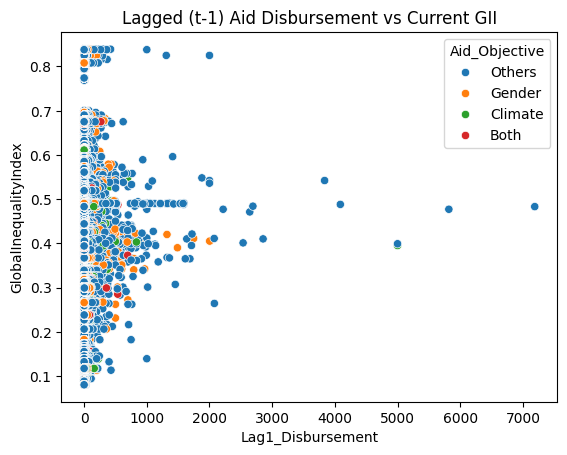

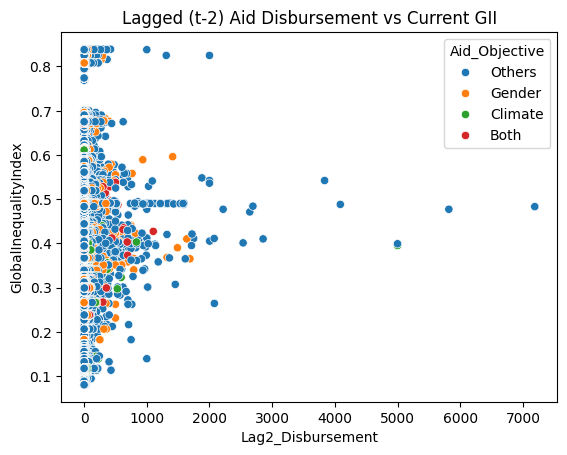

In [32]:
# 1-year lag scatterplot
sns.scatterplot(
    data=merged_df, 
    x='Lag1_Disbursement', 
    y='GlobalInequalityIndex',
    hue='Aid_Objective'
)
plt.title('Lagged (t-1) Aid Disbursement vs Current GII')
plt.show()

# 2-year lag scatterplot
sns.scatterplot(
    data=merged_df, 
    x='Lag2_Disbursement', 
    y='GlobalInequalityIndex',
    hue='Aid_Objective'
)
plt.title('Lagged (t-2) Aid Disbursement vs Current GII')
plt.show()

The scatter plots show no obvious relationship between lagged aid disbursement and gender inequality (GII). Even countries receiving very high aid amounts do not consistently display lower GII values. This suggests that the impact of aid on gender inequality is not immediate and may depend on long-term structural factors, rather than short-term funding levels.

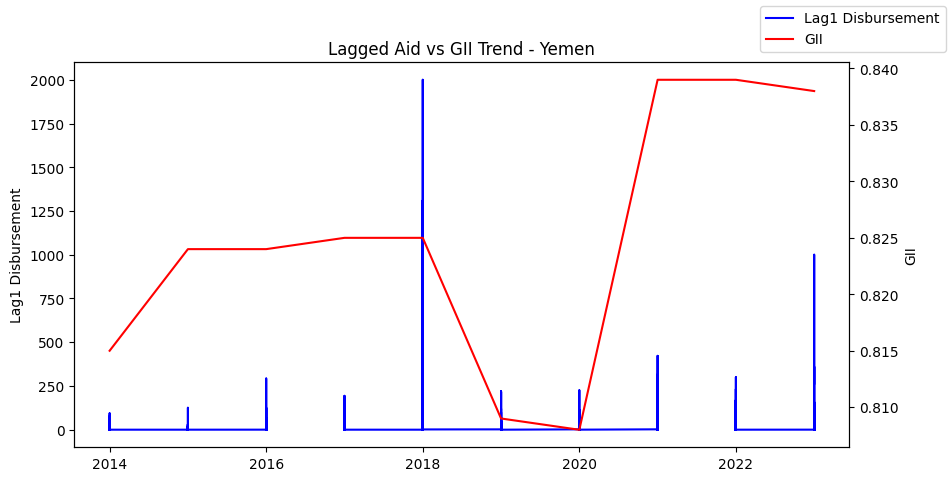

In [33]:
# Example: plot for one country (Yemen)
country = "Yemen"
df_country = merged_df[merged_df['Country'] == country]

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(df_country['Year'], df_country['Lag1_Disbursement'], label='Lag1 Disbursement', color='blue')
ax2 = ax1.twinx()
ax2.plot(df_country['Year'], df_country['GlobalInequalityIndex'], label='GII', color='red')
ax1.set_ylabel('Lag1 Disbursement')
ax2.set_ylabel('GII')
plt.title(f'Lagged Aid vs GII Trend - {country}')
fig.legend(loc="upper right")
plt.show()


In Yemen, lagged aid disbursements do not show a clear link with improvements in gender inequality. Despite occasional spikes in aid, GII remained high and even increased in recent years. This pattern suggests that in fragile states like Yemen, the effectiveness of aid on gender outcomes is heavily constrained by ongoing conflict and instability